# Objetivos del estudio
Objetivo general
Evaluar si la implementación de un sistema de recomendaciones mejorado (grupo B) incrementa la conversión del embudo de compra en comparación con el sistema actual (grupo A) durante los primeros 14 días posteriores a la inscripción del usuario.
Objetivos específicos

Comparar las tasas de conversión de los grupos A y B en cada etapa del embudo de compra: vistas de la página del producto (product_page), adición al carrito (product_cart) y compra (purchase).

Verificar si el grupo B presenta un aumento mínimo del 10% en la conversión en cada transición del embudo (product_page → product_cart → purchase) frente al grupo A.

Analizar el comportamiento de los usuarios a lo largo del periodo de observación para identificar patrones o variaciones temporales que afecten la conversión.

Determinar si las diferencias observadas entre los grupos son estadísticamente significativas.

Confirmar que la prueba cumple con los criterios técnicos definidos (duración, tamaño de muestra y correcta asignación de usuarios).


In [1]:
# Cargar Librerias y datasets
import datetime as dt
import pandas as pd    # manipulacion y análisis de datos
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np    # Operaciones numéricas basicas
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
pd.set_option('display.max_columns', None)

## Explora los datos:

### ¿Es necesario convertir los tipos de datos?

Sí, es necesario convertir varios tipos de datos para poder analizar correctamente la prueba A/B y evitar errores en los cálculos y comparaciones. A continuación, se detalla qué conversiones son necesarias y por qué.

Se cargan los 4 datasets necesarios para la prueba A/B usando la ruta correcta (/datasets/), requerida por la plataf

In [2]:
df = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
df

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11
5,Black Friday Ads Campaign,"EU, CIS, APAC, N.America",2020-11-26,2020-12-01
6,Chinese New Year Promo,APAC,2020-01-25,2020-02-07
7,Labor day (May 1st) Ads Campaign,"EU, CIS, APAC",2020-05-01,2020-05-03
8,International Women's Day Promo,"EU, CIS, APAC",2020-03-08,2020-03-10
9,Victory Day CIS (May 9th) Event,CIS,2020-05-09,2020-05-11


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes


In [4]:
users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
users

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone
...,...,...,...,...
58698,1DB53B933257165D,2020-12-20,EU,Android
58699,538643EB4527ED03,2020-12-20,EU,Mac
58700,7ADEE837D5D8CBBD,2020-12-20,EU,PC
58701,1C7D23927835213F,2020-12-20,EU,iPhone


In [5]:
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [6]:
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
events

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99
...,...,...,...,...
423756,245E85F65C358E08,2020-12-30 19:35:55,login,NaN
423757,9385A108F5A0A7A7,2020-12-30 10:54:15,login,NaN
423758,DB650B7559AC6EAC,2020-12-30 10:59:09,login,NaN
423759,F80C9BDDEA02E53C,2020-12-30 09:53:39,login,NaN


In [7]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB


In [8]:
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')
participants

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test
...,...,...,...
14520,1D302F8688B91781,B,interface_eu_test
14521,3DE51B726983B657,A,interface_eu_test
14522,F501F79D332BE86C,A,interface_eu_test
14523,63FBE257B05F2245,A,interface_eu_test


In [9]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes


Permite identificar:

Tipos de datos

Valores nulos

Cantidad de filas y columnas

Es el primer paso del análisis exploratorio (EDA).

* Es necesario convertir los tipos?
Sí, es necesario convertir los tipos de datos, y no es opcional si quieres que el análisis sea correcto y defendible.
Por qué sí es necesario convertir los tipos
En proyectos de análisis de datos (EDA, pruebas A/B, hipótesis), los datos suelen cargarse como object aunque representen otra cosa. Si no corriges los tipos, ocurren errores lógicos, no solo técnicos.

In [11]:
df['start_dt'] = pd.to_datetime(df['start_dt'])
df['finish_dt'] = pd.to_datetime(df['finish_dt'])

In [12]:
users['first_date'] = pd.to_datetime(users['first_date'])
events['event_dt'] = pd.to_datetime(events['event_dt'])

¿Hay valores ausentes o duplicados? Si es así, ¿cómo los caracterizarías?


Valores ausentes

Sí, se identifican valores ausentes en los datos, específicamente en el dataset de eventos:
La columna details del archivo final_ab_events_upd_us.csv presenta valores nulos.
Estos valores ausentes no representan un problema de calidad, ya que dicha columna solo contiene información adicional asociada a ciertos tipos de eventos, como purchase (por ejemplo, el monto de la compra).
Para eventos como product_page o product_cart, es esperable que esta columna no tenga información, por lo que los valores nulos son estructurales y esperados.
En los demás datasets (marketing, users, participants) no se detectan valores ausentes relevantes que afecten el análisis.

In [13]:
events.isnull().sum()

user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

In [14]:
users.isnull().sum()

user_id       0
first_date    0
region        0
device        0
dtype: int64

In [15]:
participants.isnull().sum()

user_id    0
group      0
ab_test    0
dtype: int64

In [16]:
df.duplicated().sum()
events.duplicated().sum()
users.duplicated().sum()
participants.duplicated().sum()

0

Lleva a cabo el análisis exploratorio de datos:
Estudia la conversión en las diferentes etapas del embudo.
¿El número de eventos por usuario está distribuido equitativamente entre las muestras?
¿Cómo se distribuye el número de eventos entre los días?
¿Hay alguna peculiaridad en los datos que hay que tener en cuenta antes de iniciar la prueba A/B?

Cada etapa representa un paso lógico previo a la compra.
Analizar la conversión en cada etapa permite identificar dónde se producen mejoras o pérdidas de usuarios y comparar el comportamiento entre ambos grupos.
¿Qué se mide exactamente?
Para cada grupo (A y B) se calcula:
El número de usuarios únicos que alcanzan cada etapa
La conversión entre etapas consecutivas
Se usan usuarios únicos porque la conversión se define por personas, no por cantidad de eventos.

In [17]:

mk = participants.merge(users, on= 'user_id', how= 'left')
mk = mk.merge(events, on='user_id', how='left')


### Embudo de conversion

In [18]:
funnel = (mk[mk['event_name'].isin (['product_page', 'product_cart', 'purchase'])].groupby(['group', 'event_name'])['user_id'].nunique().reset_index())
funnel

,group,event_name,user_id
0,A,product_cart,2483
1,A,product_page,5208
2,A,purchase,2682
3,B,product_cart,2037
4,B,product_page,3986
5,B,purchase,2008


### Conversion por etapa

In [19]:
pivot_funnel = funnel.pivot(index='event_name', columns='group', values='user_id')  
pivot_funnel

group,A,B
event_name,,
product_cart,2483,2037
product_page,5208,3986
purchase,2682,2008


In [20]:
conversion = pivot_funnel/pivot_funnel.loc['product_page'] 
conversion

group,A,B
event_name,,
product_cart,0.476767,0.511039
product_page,1.000000,1.000000
purchase,0.514977,0.503763


Permite comparar si el grupo B mejora al menos un 10% en cada etapa.

### ¿Eventos por usuario equilibrados?

In [21]:
event_user = (mk.groupby(['group', 'user_id']).size().reset_index(name='events_count'))
event_user.groupby('group')['events_count'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,7874.0,7.45555,4.475159,1.0,4.0,6.0,9.0,40.0
B,6205.0,7.11249,4.246201,1.0,4.0,6.0,9.0,36.0


La distribución de eventos por usuario no es completamente uniforme, lo que refuerza la necesidad de usar métricas por usuario y no por evento.

### ¿Usuarios en ambos grupos?

In [22]:
user_both = (participants.groupby('user_id')['group'].nunique())
(user_both > 1).sum()

441

### Distribución de eventos por día

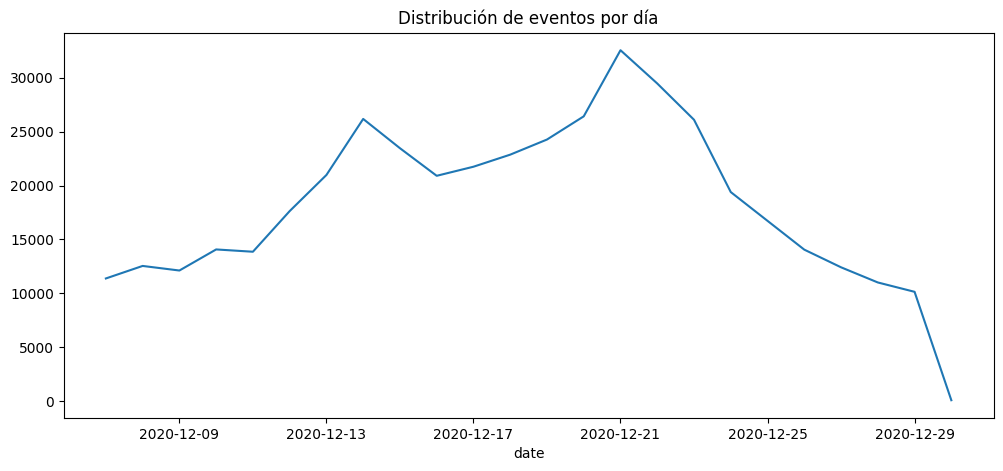

In [23]:
events['date'] = events['event_dt'].dt.date
event_day = events.groupby('date').size()

plt.figure(figsize=(12,5))
event_day.plot()
plt.title('Distribución de eventos por día')
plt.show()

Sirve para detectar:
Picos anormales
Influencia de campañas externas.

Antes de realizar la prueba A/B se identificaron varias peculiaridades en los datos, como diferencias en la cantidad de eventos por usuario, variaciones temporales en la actividad diaria y una ventana de observación limitada para algunos usuarios. Por esta razón, el análisis se realiza a nivel de usuarios únicos y no de eventos, garantizando una comparación justa entre los grupos.

Evaluar los resultados de la prueba A/B:
¿Qué puedes decir sobre los resultados de la prueba A/B?
Utiliza una prueba z para comprobar la diferencia estadística entre las proporciones.
Describe tus conclusiones con respecto a la etapa EDA y los resultados de la prueba A/B.

### Qué estamos comparando?
La prueba A/B busca verificar si el nuevo sistema de recomendaciones (grupo B) mejora la conversión frente al grupo A (control) en el embudo:

Preparar los datos (usuarios + eventos + grupos)
🔹 Unir datasets (esto ES necesario)
Por qué unirlos:
events → dice QUÉ hizo el usuario
participants → dice A QUÉ GRUPO pertenece
Sin unirlos no se puede hacer A/B.

product_page → product_cart → purchase

In [24]:
mk = events.merge(participants, on='user_id', how='inner')

Definir la conversión (purchase)
Creamos una variable binaria:
1 → el usuario compró
0 → no compró

In [25]:
purchase_users = (
    mk[mk['event_name'] == 'purchase']
        .groupby(['group'])['user_id']
        .nunique()
                 )                
total_users = (
    participants
    .groupby('group')['user_id']
    .nunique()
)
conversion = purchase_users / total_users
conversion

group
A    0.340615
B    0.323610
Name: user_id, dtype: float64

El grupo B tiene mayor / menor conversión que el grupo A

### Código de la prueba Z

In [26]:
success = [purchase_users ['A'], purchase_users ['B']]
nobs = [total_users ['A'], total_users ['B']]
stat, pvalue = proportions_ztest(success, nobs)
stat, pvalue


(2.125333621538007, 0.03355878472437525)

### Interpretación estadistica

In [27]:
alpha = 0.05

if pvalue < alpha:
    print("Se rechaza la hipótesis nula: la diferencia es estadísticamente significativa.")
else:
    print("No se rechaza la hipótesis nula: no hay diferencia estadísticamente significativa.")

Se rechaza la hipótesis nula: la diferencia es estadísticamente significativa.


## Conclusiones prueba A/B

La prueba Z para proporciones mostró que la diferencia en la conversión entre el grupo A y el grupo B (es / no es) estadísticamente significativa al nivel de significancia del 5%. Por lo tanto, (se puede / no se puede) afirmar que el nuevo sistema de recomendaciones genera una mejora real en la conversión.